In [1]:
# ✅ Balancing Dataset Function

from sklearn.utils import resample

def get_balanced_dataset():
    df = pd.read_csv("TweetSentiment.csv", encoding="ISO-8859-1")[["text", "sentiment"]]
    df.dropna(inplace=True)

    max_size = df["sentiment"].value_counts().max()
    df_balanced = pd.concat([
        resample(class_df, replace=True, n_samples=max_size, random_state=42)
        for _, class_df in df.groupby("sentiment")
    ])

    return df_balanced


--- Binary BERT + RNN ---
              precision    recall  f1-score   support

           0     0.9732    0.9649    0.9691      2224
           1     0.9652    0.9735    0.9693      2223

    accuracy                         0.9692      4447
   macro avg     0.9692    0.9692    0.9692      4447
weighted avg     0.9692    0.9692    0.9692      4447



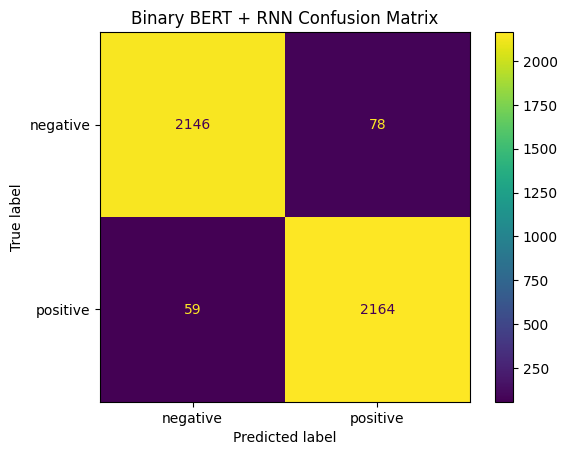


--- Multiclass BERT + RNN ---
              precision    recall  f1-score   support

           0     0.8919    0.9208    0.9062      2223
           1     0.8682    0.8386    0.8532      2224
           2     0.9201    0.9218    0.9209      2224

    accuracy                         0.8937      6671
   macro avg     0.8934    0.8937    0.8934      6671
weighted avg     0.8934    0.8937    0.8934      6671



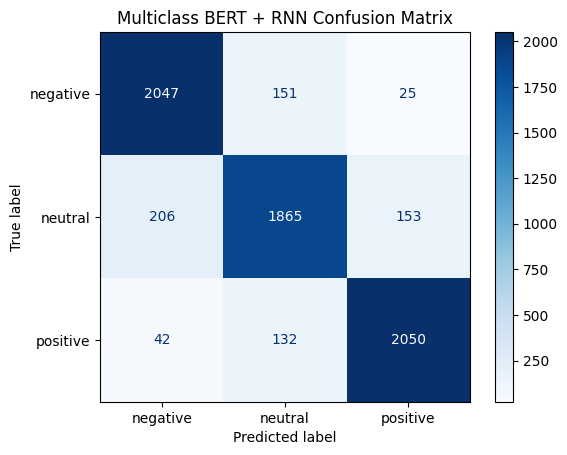

In [14]:
# ✅ BERT + RNN

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors='pt')
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

class BERT_RNN(nn.Module):
    def __init__(self, hidden_dim, output_dim, rnn_type='lstm', dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.rnn_type = rnn_type.lower()
        self.hidden_dim = hidden_dim

        if self.rnn_type == 'gru':
            self.rnn = nn.GRU(self.bert.config.hidden_size, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.LSTM(self.bert.config.hidden_size, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_outputs.last_hidden_state
        _, hidden = self.rnn(sequence_output)

        if self.rnn_type == 'lstm':
            hidden = hidden[0]

        output = self.fc(self.dropout(hidden[-1]))
        return output

def run_rnn_pipeline(df, title_prefix):
    df["label"] = df["sentiment"].astype("category").cat.codes
    num_classes = df["label"].nunique()

    label_to_sentiment = dict(enumerate(df["sentiment"].astype("category").cat.categories))
    
    X_train, X_test, y_train, y_test = train_test_split(
        df["text"], df["label"], test_size=0.2, stratify=df["label"], random_state=SEED
    )

    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    train_dataset = TweetDataset(X_train, y_train, tokenizer)
    test_dataset = TweetDataset(X_test, y_test, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    model = BERT_RNN(hidden_dim=1024, output_dim=num_classes, rnn_type='lstm').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(15):
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- {title_prefix} BERT + RNN ---")
    print(classification_report(all_labels, all_preds, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    if num_classes == 3:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_to_sentiment[i] for i in range(3)])
        disp.plot(cmap="Blues")
    else:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_to_sentiment[i] for i in range(2)])
        disp.plot()

    plt.title(f"{title_prefix} BERT + RNN Confusion Matrix")
    plt.show()

df = get_balanced_dataset()

df_binary = df[df["sentiment"].isin(["positive", "negative"])].copy()
run_rnn_pipeline(df_binary, "Binary")

df_multiclass = df.copy()
run_rnn_pipeline(df_multiclass, "Multiclass")

In [ ]:
# ✅ Hyperparameter Search

import random
import itertools
from sklearn.metrics import accuracy_score
from copy import deepcopy
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn

search_space = {
    "hidden_dim": [2048, 1024],
    "dropout": [0.3],
    "lr": [1e-3],
    "rnn_type": ["lstm", "gru"],
    "batch_size": [32],
    "epochs": [15]
}

def grid_search(df, tokenizer, max_length=64):
    df["label"] = df["sentiment"].astype("category").cat.codes
    num_classes = df["label"].nunique()

    X_train, X_val, y_train, y_val = train_test_split(
        df["text"], df["label"], test_size=0.2, stratify=df["label"], random_state=SEED
    )

    best_score = 0
    best_params = None

    keys = list(search_space.keys())
    all_combinations = list(itertools.product(*[search_space[key] for key in keys]))
    print(f"🔍 Total combinations: {len(all_combinations)}")

    for i, values in enumerate(all_combinations):
        params = dict(zip(keys, values))
        print(f"\n🧪 Trial {i+1}/{len(all_combinations)} with params: {params}")

        train_dataset = TweetDataset(X_train, y_train, tokenizer, max_length)
        val_dataset = TweetDataset(X_val, y_val, tokenizer, max_length)

        train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)

        model = BERT_RNN(
            hidden_dim=params["hidden_dim"],
            output_dim=num_classes,
            rnn_type=params["rnn_type"],
            dropout=params["dropout"]
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=params["lr"])
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(params["epochs"]):
            for batch in train_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                optimizer.zero_grad()
                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(input_ids, attention_mask)
                pred = torch.argmax(outputs, dim=1)
                preds.extend(pred.cpu().numpy())
                true.extend(labels.cpu().numpy())

        acc = accuracy_score(true, preds)
        print(f"Validation Accuracy: {acc:.4f}")

        if acc > best_score:
            best_score = acc
            best_params = deepcopy(params)

    print("\n✅ Best Parameters:")
    print(best_params)
    print(f"🎯 Best Validation Accuracy: {best_score:.4f}")
    return best_params

def random_search(
    df, tokenizer, n_trials=10, max_length=64
):
    df["label"] = df["sentiment"].astype("category").cat.codes
    num_classes = df["label"].nunique()
    
    X_train, X_val, y_train, y_val = train_test_split(
        df["text"], df["label"], test_size=0.2, stratify=df["label"], random_state=SEED
    )
    
    best_score = 0
    best_params = None

    for trial in range(n_trials):
        params = {
            "hidden_dim": random.choice(search_space["hidden_dim"]),
            "dropout": random.choice(search_space["dropout"]),
            "lr": random.choice(search_space["lr"]),
            "rnn_type": random.choice(search_space["rnn_type"]),
            "batch_size": random.choice(search_space["batch_size"]),
            "epochs": random.choice(search_space["epochs"]),
        }

        print(f"\n🧪 Trial {trial+1}/{n_trials} with params: {params}")

        train_dataset = TweetDataset(X_train, y_train, tokenizer, max_length)
        val_dataset = TweetDataset(X_val, y_val, tokenizer, max_length)

        train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)

        model = BERT_RNN(
            hidden_dim=params["hidden_dim"],
            output_dim=num_classes,
            rnn_type=params["rnn_type"],
            dropout=params["dropout"]
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=params["lr"])
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(params["epochs"]):
            for batch in train_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                optimizer.zero_grad()
                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(input_ids, attention_mask)
                pred = torch.argmax(outputs, dim=1)
                preds.extend(pred.cpu().numpy())
                true.extend(labels.cpu().numpy())

        acc = accuracy_score(true, preds)
        print(f"Validation Accuracy: {acc:.4f}")

        if acc > best_score:
            best_score = acc
            best_params = deepcopy(params)

    print("\n✅ Best Parameters:")
    print(best_params)
    print(f"🎯 Best Validation Accuracy: {best_score:.4f}")
    return best_params

grid_best_params = grid_search(df, BertTokenizer.from_pretrained('bert-base-uncased'))

🔍 Total combinations: 3

🧪 Trial 1/3 with params: {'hidden_dim': 512, 'dropout': 0.3, 'lr': 0.001, 'rnn_type': 'lstm', 'batch_size': 32, 'epochs': 5}
Validation Accuracy: 0.8134

🧪 Trial 2/3 with params: {'hidden_dim': 1024, 'dropout': 0.3, 'lr': 0.001, 'rnn_type': 'lstm', 'batch_size': 32, 'epochs': 5}
Validation Accuracy: 0.8386

🧪 Trial 3/3 with params: {'hidden_dim': 4096, 'dropout': 0.3, 'lr': 0.001, 'rnn_type': 'lstm', 'batch_size': 32, 'epochs': 5}
Validation Accuracy: 0.5678

✅ Best Parameters:
{'hidden_dim': 2048, 'dropout': 0.3, 'lr': 0.001, 'rnn_type': 'lstm', 'batch_size': 32, 'epochs': 5}
🎯 Best Validation Accuracy: 0.8386
